In [1]:
!rm -rf fraud-detection-pytorch

!git clone https://github.com/deenyzx/fraud-detection-pytorch.git

%cd fraud-detection-pytorch

Cloning into 'fraud-detection-pytorch'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 112 (delta 47), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 21.45 MiB | 8.42 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/fraud-detection-pytorch


In [2]:
!pip install -r requirements.txt

In [ ]:
!python main.py

Using device: cuda

--- Step 1: Preparing Data ---
Extracting and loading: transactions.csv
Successfully engineered 'cvv_match' feature from cardcvv and enteredcvv.
Data ready. Input dimensions (number of features): 6

--- Step 2: Initializing Model ---
AnomalyAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=6, bias=True)
  )
)

--- Step 3: Training Model ---
Training starting...
Epoch 01/20 | Train

Using device: cuda
Extracting and loading: transactions.csv
Successfully engineered 'cvv_match' feature from cardcvv and enteredcvv.
Model and test data successfully loaded.



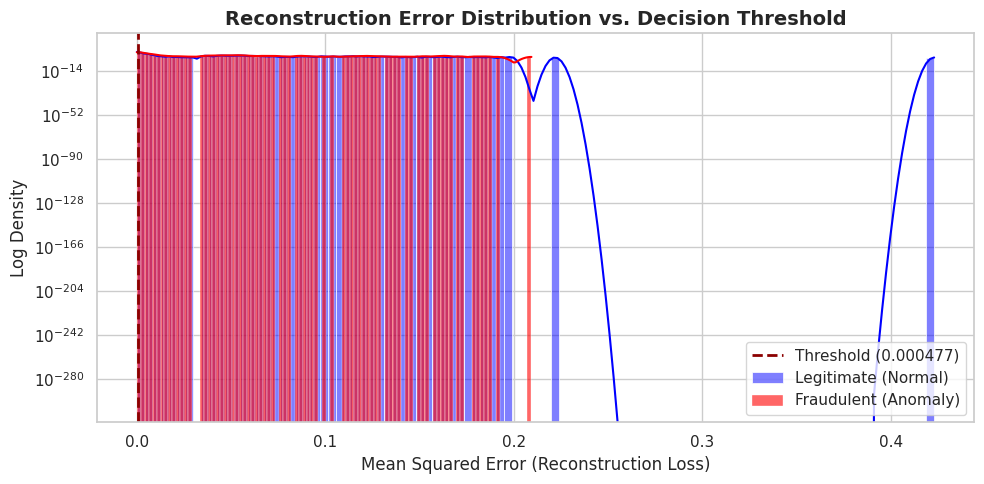

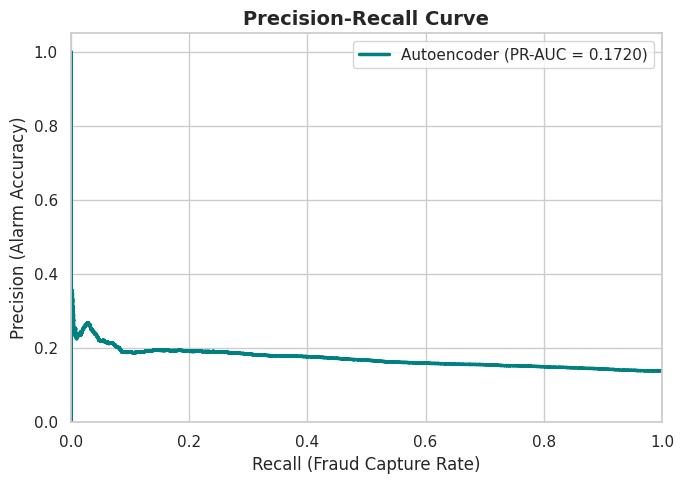

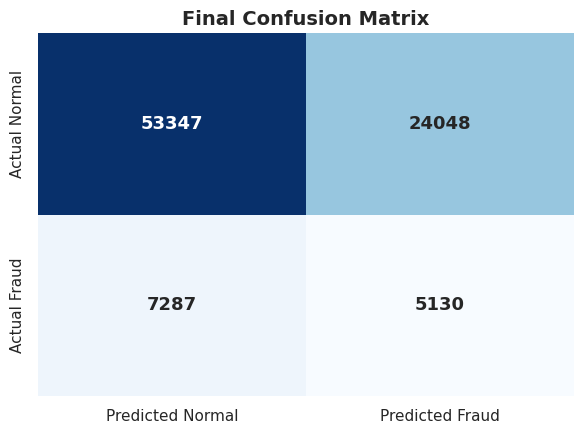

In [ ]:
import sys
import os

# 1. TELL PYTHON WHERE YOUR REPOSITORY IS
# This ensures that 'src' can be imported without any ModuleNotFoundError
repo_path = '/content/fraud-detection-pytorch'  # Double-check if your folder name matches exactly
if repo_path not in sys.path:
    sys.path.append(repo_path)

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from src.data_loader import prepare_data
from src.model import AnomalyAutoencoder

# Set professional visualization style
sns.set_theme(style="whitegrid")

# 2. LOAD DATA AND TRAINED MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ingest test data using your modular loader
_, _, X_test, y_test, input_dim = prepare_data('data/creditcard.zip', batch_size=256)

# Initialize and load weights
model = AnomalyAutoencoder(input_dim=input_dim).to(device)
model.load_state_dict(torch.load('models/autoencoder_fraud.pth', map_location=device))
model.eval()
print("Model and test data successfully loaded.\n")

# 3. COMPUTE RECONSTRUCTION ERRORS
X_test_tensor = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    reconstructed = model(X_test_tensor)

# Calculate Mean Squared Error (MSE) per transaction
mse = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1)
reconstruction_errors = mse.cpu().numpy()

# Set your exact optimal threshold from main.py execution
optimal_threshold = 0.000477
predictions = (reconstruction_errors > optimal_threshold).astype(int)

# ==========================================
# CHART 1: RECONSTRUCTION ERROR DISTRIBUTION
# ==========================================
plt.figure(figsize=(10, 5))
sns.histplot(reconstruction_errors[y_test == 0], bins=100, kde=True, color='blue', label='Legitimate (Normal)', stat='density', alpha=0.5)
sns.histplot(reconstruction_errors[y_test == 1], bins=100, kde=True, color='red', label='Fraudulent (Anomaly)', stat='density', alpha=0.6)
plt.axvline(optimal_threshold, color='darkred', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.6f})')
plt.yscale('log')  # Log scale helps visualize highly skewed financial data margins
plt.title('Reconstruction Error Distribution vs. Decision Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Mean Squared Error (Reconstruction Loss)', fontsize=12)
plt.ylabel('Log Density', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: PRECISION-RECALL CURVE
# ==========================================
precisions, recalls, _ = precision_recall_curve(y_test, reconstruction_errors)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='teal', linewidth=2.5, label=f'Autoencoder (PR-AUC = {pr_auc:.4f})')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Fraud Capture Rate)', fontsize=12)
plt.ylabel('Precision (Alarm Accuracy)', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: FINAL CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Final Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()